# Policy rollouts

## Imports & global configurations

In [1]:
import sys
sys.path.append("..")

from source.policy import HeuristicPolicy, NeuralPolicy
from source.simulation import rollout_trajectory, sample_initial_state
from source.stochastic_processes import make_price_function
from source.system import SystemParams
from source.utils import read_csv
from source.plotting import *
from source.diagnostics import check_energy_balance

import torch

import matplotlib.pyplot as plt
plt.style.use("../styles/paper.mplstyle")

In [2]:
global_seed = 123

device = torch.device("cpu")
batch_size = 1000

params = SystemParams()

S0 = sample_initial_state(
    batch_size=batch_size,
    params=params,
    device=device,
    seed=global_seed
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

results = {}

## Heuristic Policy

In [3]:
next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = HeuristicPolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["heuristic"] = history

In [4]:
check_energy_balance(history, params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 34.942161560058594,
 'max_Ub': 432.0}

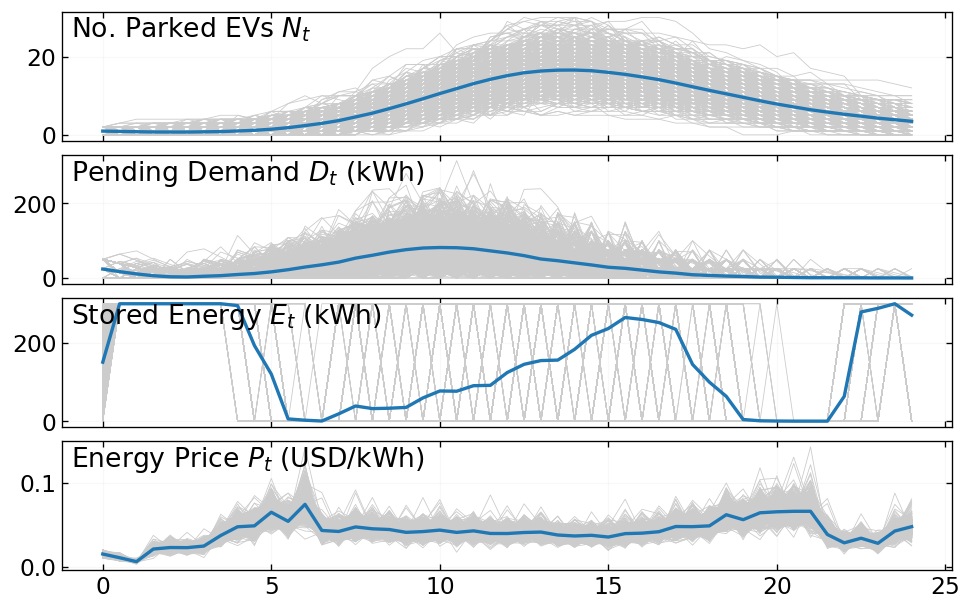

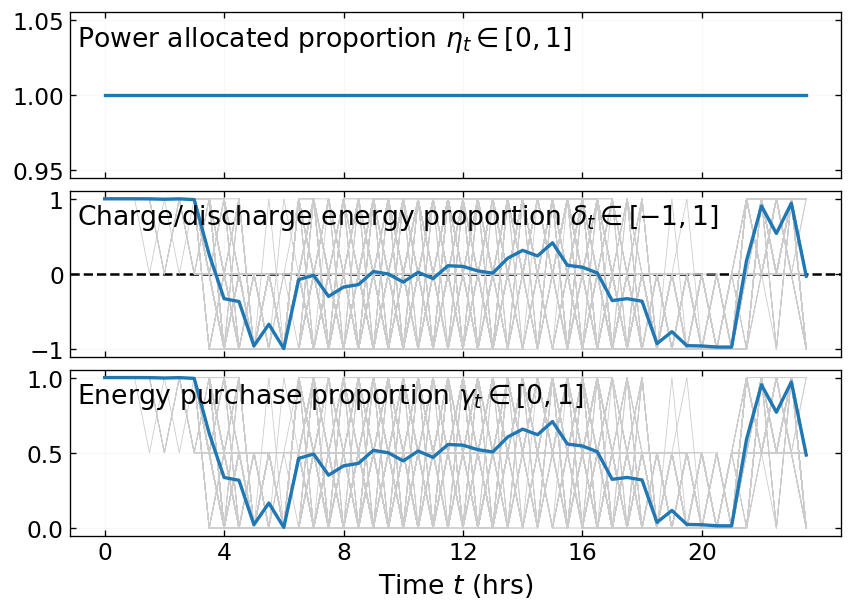

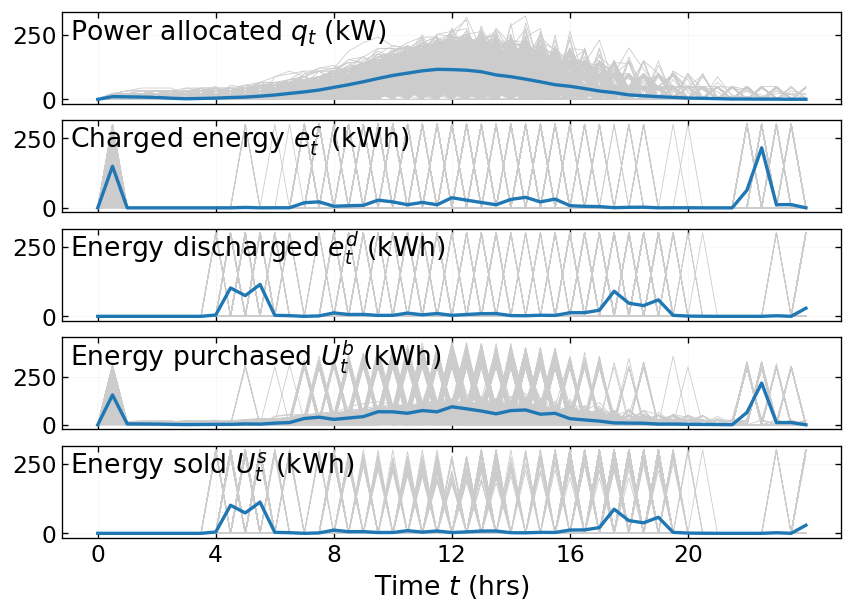

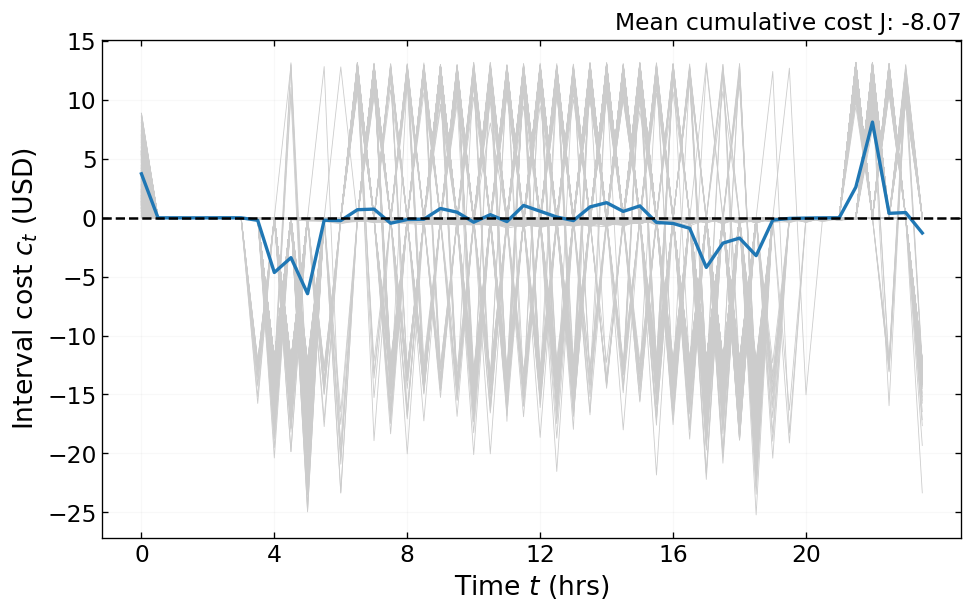

In [5]:
plot_state_trajectories(
    history, save_path="../figures/heuristic_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/heuristic_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/heuristic_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/heuristic_policy/cost.pdf"
)

## Untrained Neural Policy 

In [6]:
from pathlib import Path
import torch

In [7]:
torch.manual_seed(global_seed)
policy = NeuralPolicy()

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "seed": global_seed,
        "state_dict": policy.state_dict(),
        "description": "Fixed untrained policy baseline"
    },
    checkpoint_dir / "untrained_policy.pt"
)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])
policy.eval()

next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["untrained"] = history

In [8]:
check_energy_balance(history, params.dt)

{'max_abs_error': 3.814697265625e-06,
 'mean_abs_error': 1.1500047136792091e-08,
 'mean_Ub': 17.252437591552734,
 'max_Ub': 99.58191680908203}

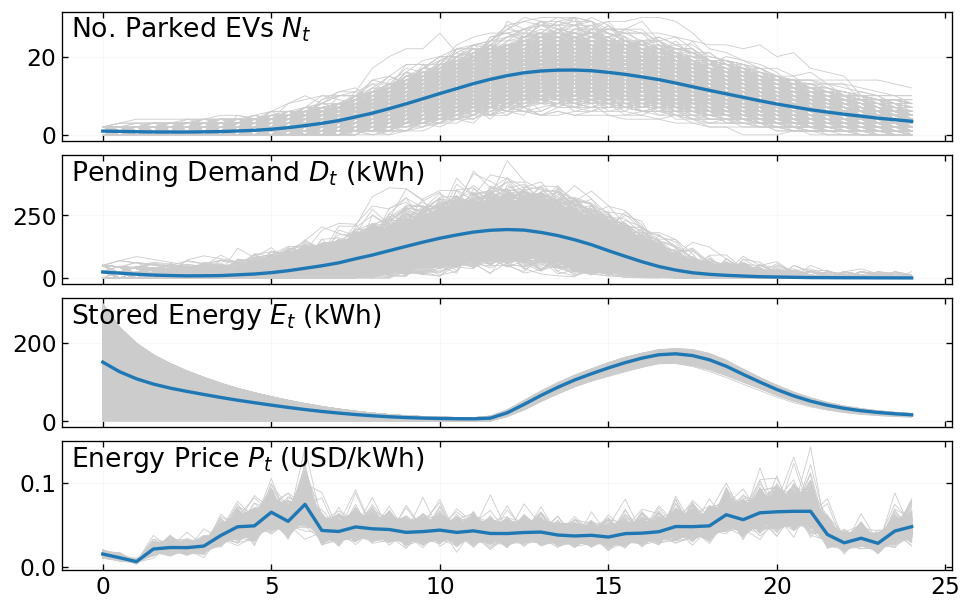

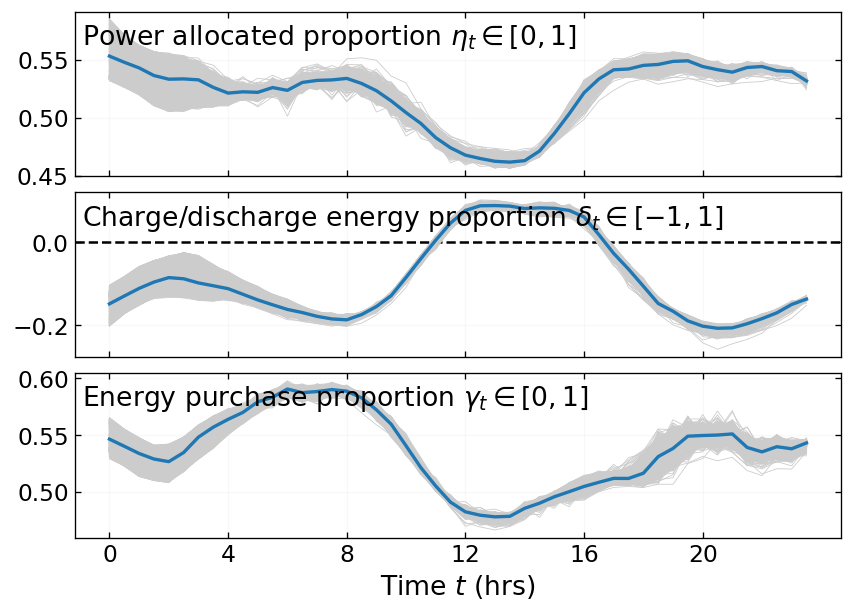

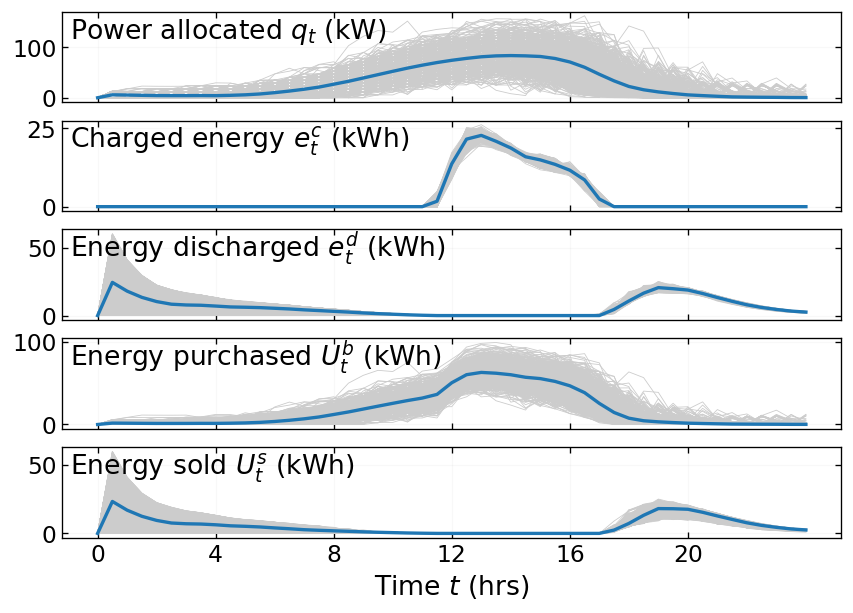

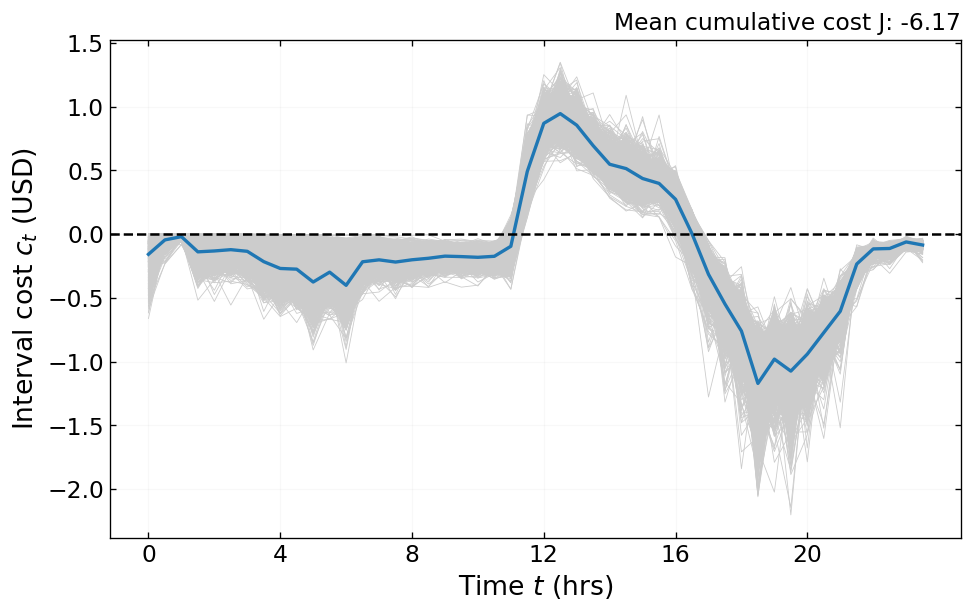

In [9]:
plot_state_trajectories(
    history, save_path="../figures/untrained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/untrained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/untrained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/untrained_policy/cost.pdf"
)

## Trained Neural Policy

In [10]:
from source.training import train_net

EPOCHS = 1000

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=device)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=device,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=batch_size,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    verbose=True,
    seed_base=global_seed
)

[050] J_train=-8.8788 | J_stoch_eval_fixed=-8.9793 | J_det_eval=-9.8512
[100] J_train=-12.4193 | J_stoch_eval_fixed=-12.5068 | J_det_eval=-12.9189
[150] J_train=-15.9300 | J_stoch_eval_fixed=-16.0280 | J_det_eval=-13.6740
[200] J_train=-18.2545 | J_stoch_eval_fixed=-18.2779 | J_det_eval=-15.0502
[250] J_train=-20.0646 | J_stoch_eval_fixed=-20.0835 | J_det_eval=-18.2064
[300] J_train=-21.5707 | J_stoch_eval_fixed=-21.4870 | J_det_eval=-18.6940
[350] J_train=-22.5794 | J_stoch_eval_fixed=-22.6066 | J_det_eval=-10.6914
[400] J_train=-23.5941 | J_stoch_eval_fixed=-23.4322 | J_det_eval=-10.8121
[450] J_train=-24.5226 | J_stoch_eval_fixed=-24.4473 | J_det_eval=-10.0867
[500] J_train=-25.6462 | J_stoch_eval_fixed=-25.5675 | J_det_eval=-8.5670
[550] J_train=-26.0774 | J_stoch_eval_fixed=-26.0775 | J_det_eval=-8.4008
[600] J_train=-26.2789 | J_stoch_eval_fixed=-26.3787 | J_det_eval=-8.1340
[650] J_train=-26.9001 | J_stoch_eval_fixed=-26.5940 | J_det_eval=-7.8911
[700] J_train=-27.2063 | J_stoch

In [12]:
res.keys()

dict_keys(['best_state', 'best_J', 'best_epoch', 'last_state', 'J_train_hist', 'J_stoch_eval_hist', 'J_det_eval_hist', 'training_steps', 'evaluation_steps', 'eval_seed', 'policy'])

In [13]:
from pathlib import Path
import torch

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "best_J": res["best_J"],
    "policy_state_dict": res["best_state"],
    "J_train_hist": res["J_train_hist"],
    'J_stoch_eval_hist': res['J_stoch_eval_hist'],
    'J_det_eval_hist': res['J_det_eval_hist'],
    "training_steps": res["training_steps"],
    "evaluation_steps": res["evaluation_steps"],
    "seed_base": global_seed,
    "epochs": EPOCHS,
    "batch_size": batch_size,
    "lr": 5e-4,
    "weight_decay": 1e-5,
}

torch.save(checkpoint, checkpoint_dir / "trained_policy.pt")

In [14]:
checkpoint = torch.load(
    "../checkpoints/policies/trained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["policy_state_dict"])
policy.eval()

next_price_fn = make_price_function(price_history, future_price, params)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    alpha_grid=0.0,
    lambda_demand=0.0,
    lambda_cost=0.0,
    seed=global_seed,
    device=device,
)

results["trained"] = history

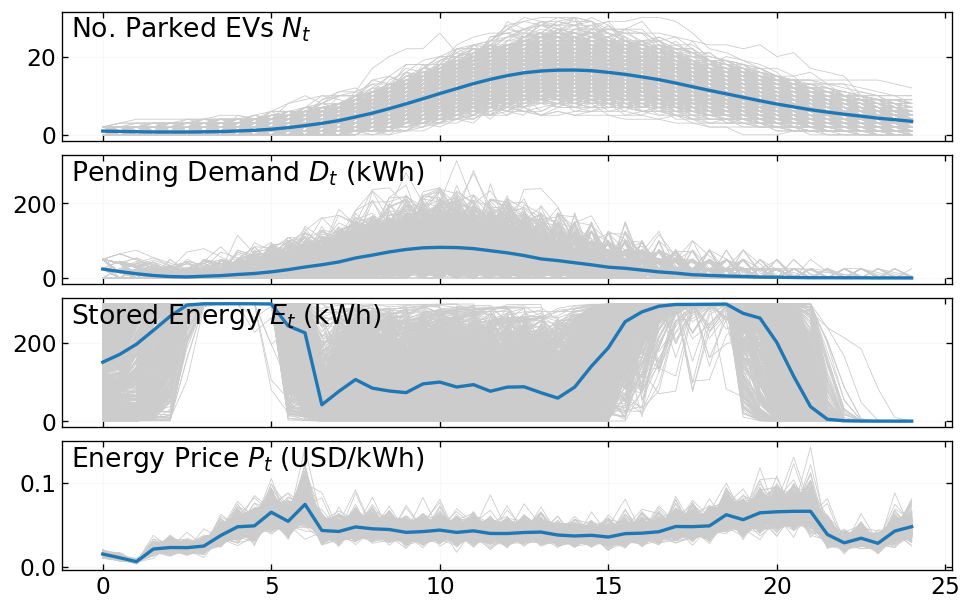

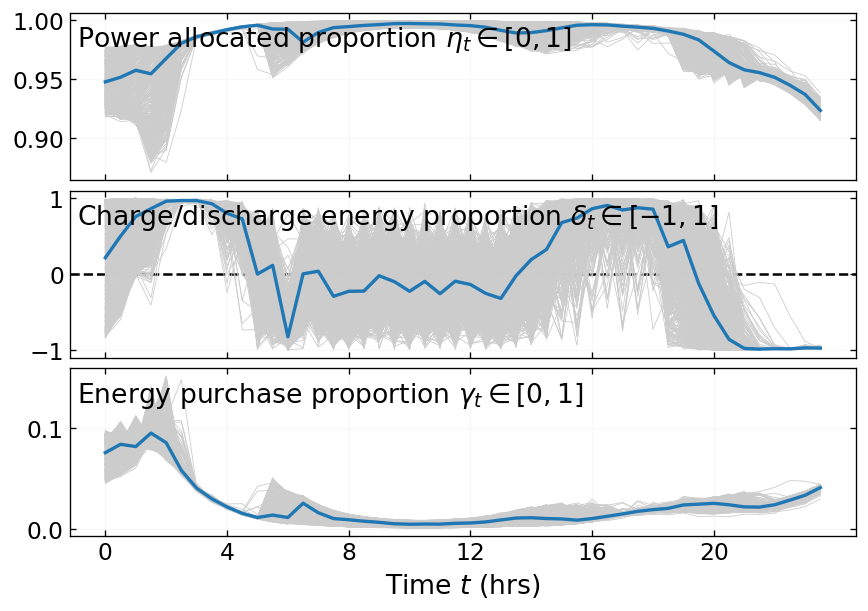

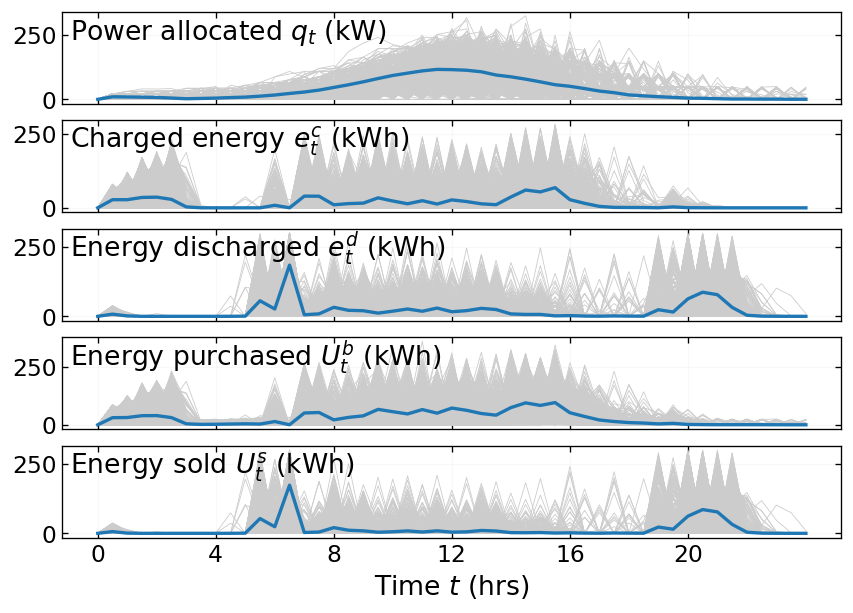

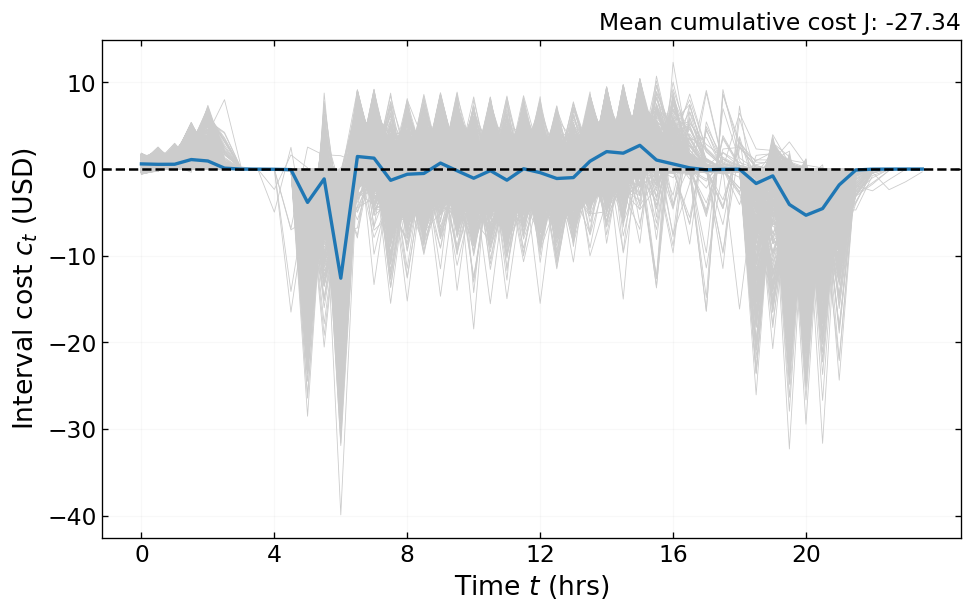

In [15]:
plot_state_trajectories(
    history, save_path="../figures/trained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/trained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/trained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/trained_policy/cost.pdf"
)

In [17]:
checkpoint.keys()

dict_keys(['best_J', 'policy_state_dict', 'J_train_hist', 'J_stoch_eval_hist', 'J_det_eval_hist', 'training_steps', 'evaluation_steps', 'seed_base', 'epochs', 'batch_size', 'lr', 'weight_decay'])

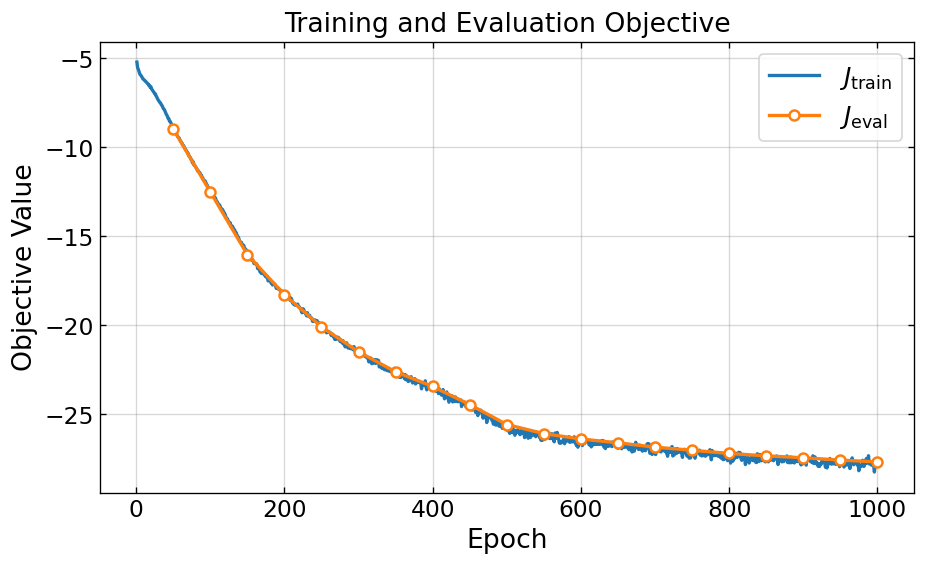

In [20]:
import os

SAVE_DIR = "../figures/trained_policy"
os.makedirs(SAVE_DIR, exist_ok=True)

J_train = checkpoint["J_train_hist"]
J_evaluation = checkpoint["J_stoch_eval_hist"]

training_steps = checkpoint["training_steps"]
evaluation_steps = checkpoint["evaluation_steps"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(training_steps, J_train, linewidth=2, label=r"$J_{\mathrm{train}}$")

ax.plot(
    evaluation_steps, J_evaluation,
    marker="o", markerfacecolor="white",
    markeredgewidth=1.5, linewidth=2,
    label=r"$J_{\mathrm{eval}}$"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Objective Value")
ax.set_title("Training and Evaluation Objective")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    os.path.join(SAVE_DIR, "training_curve.pdf"),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(SAVE_DIR, "training_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Stochastic Scenario Verification

In [21]:
print("\n" + "="*60)
print("ARRIVALS (arrival)")
print("="*60)

same = torch.allclose(
    results["untrained"]["arrival"],
    results["heuristic"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["heuristic"]["arrival"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["trained"]["arrival"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("DEPARTURES (departure)")
print("="*60)

same = torch.allclose(
    results["untrained"]["departure"],
    results["heuristic"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["heuristic"]["departure"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["trained"]["departure"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("PRICE (state[..., 3])")
print("="*60)

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["heuristic"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["heuristic"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["trained"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

A_same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)

B_same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)

P_same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)

if A_same and B_same and P_same:
    print("✅ Same stochastic scenario across policies.")
else:
    print("❌ Stochastic processes differ between policies.")
    print(f"   Arrivals equal   : {A_same}")
    print(f"   Departures equal : {B_same}")
    print(f"   Prices equal     : {P_same}")


ARRIVALS (arrival)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

DEPARTURES (departure)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

PRICE (state[..., 3])
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

SUMMARY
✅ Same stochastic scenario across policies.


In [22]:
rollout_dir = Path("../checkpoints/rollouts")
rollout_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    results,
    rollout_dir / "policy_comparison.pt"
)

# Policy comparison

In [23]:
import sys
sys.path.append("..")

import torch
from source.plotting import *

device = torch.device("cpu")

In [24]:
results = torch.load(
    "../checkpoints/rollouts/policy_comparison.pt",
    map_location=device
)

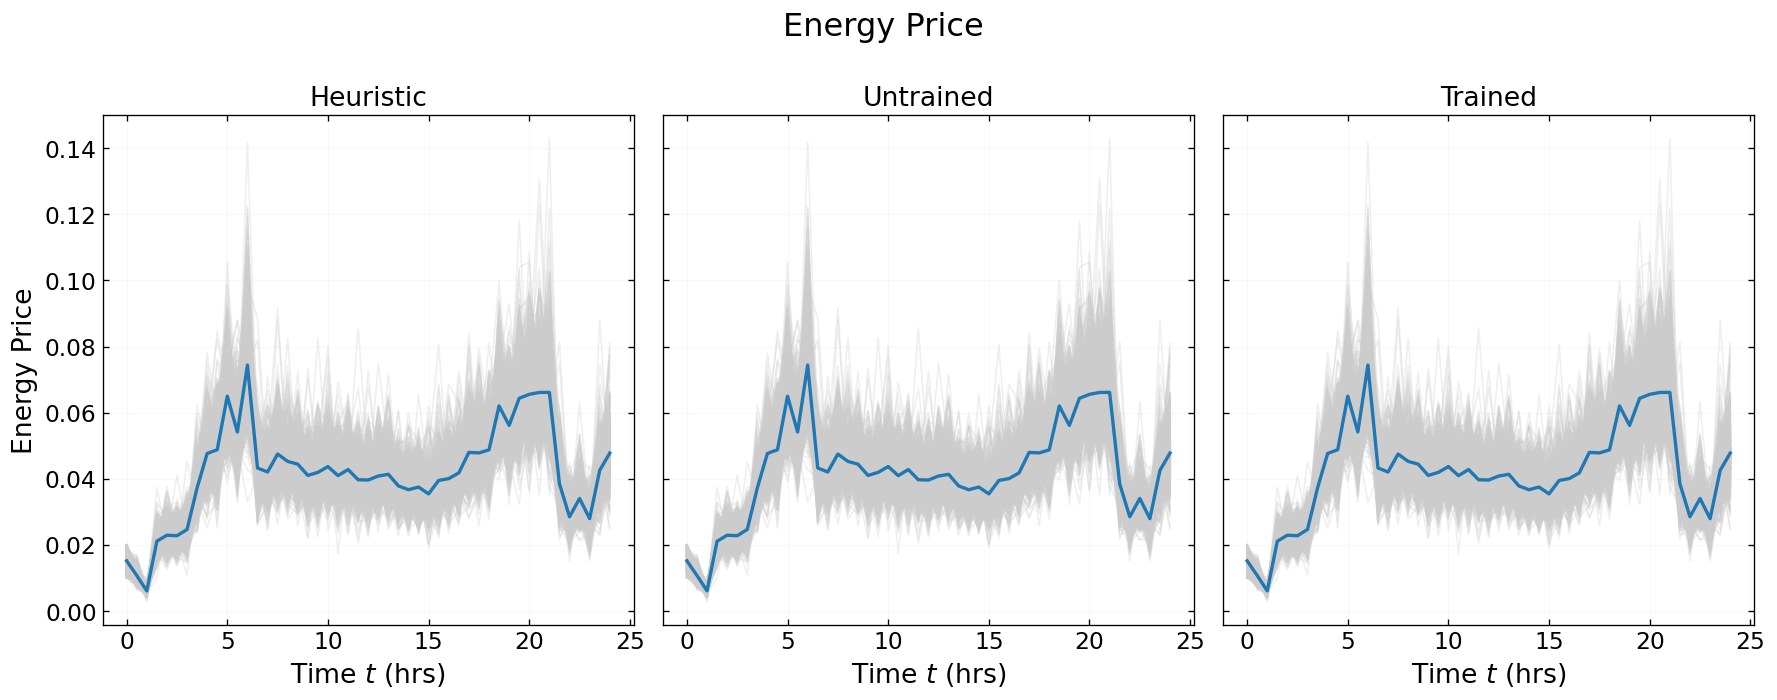

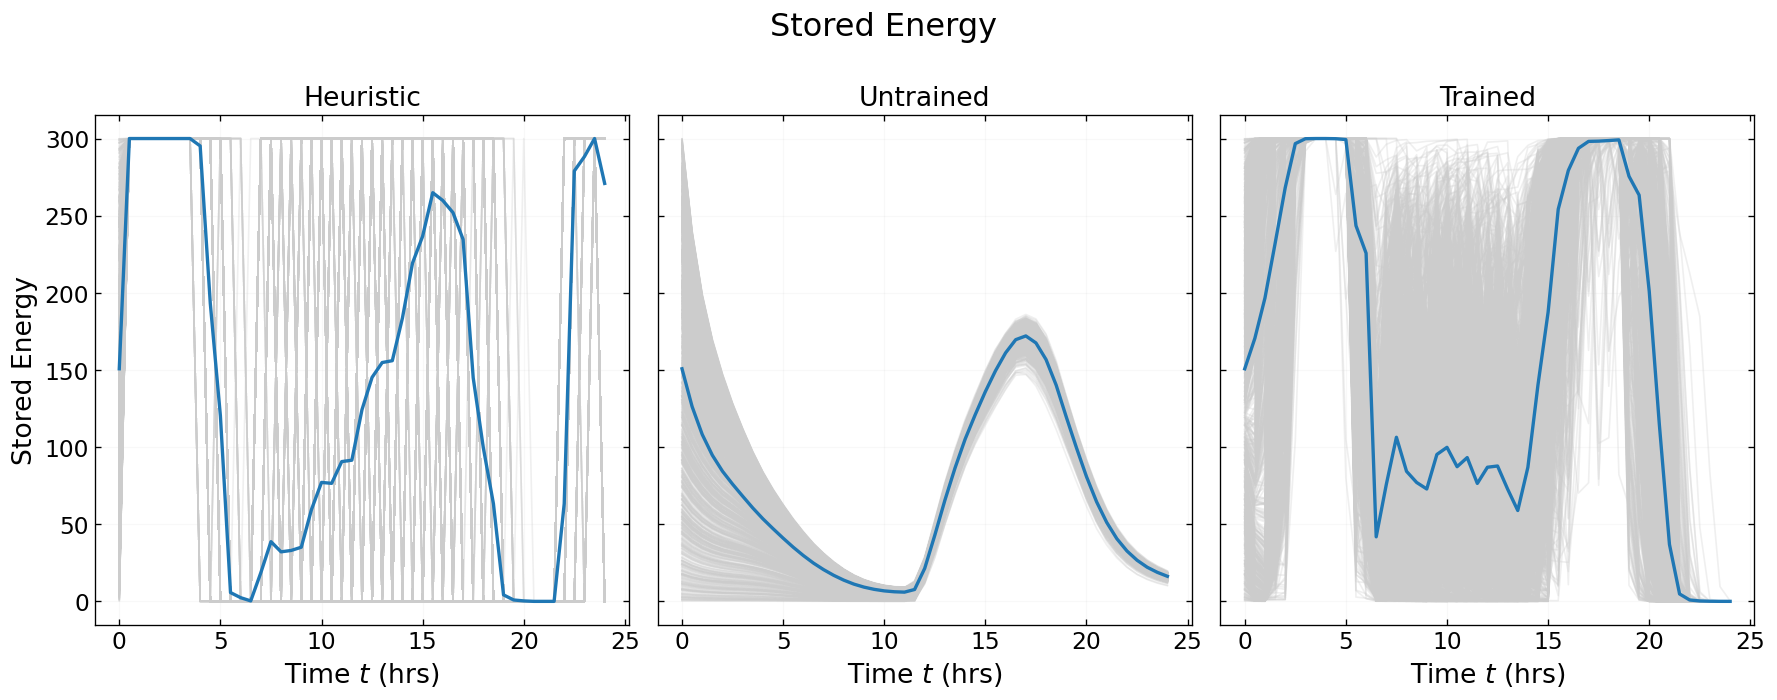

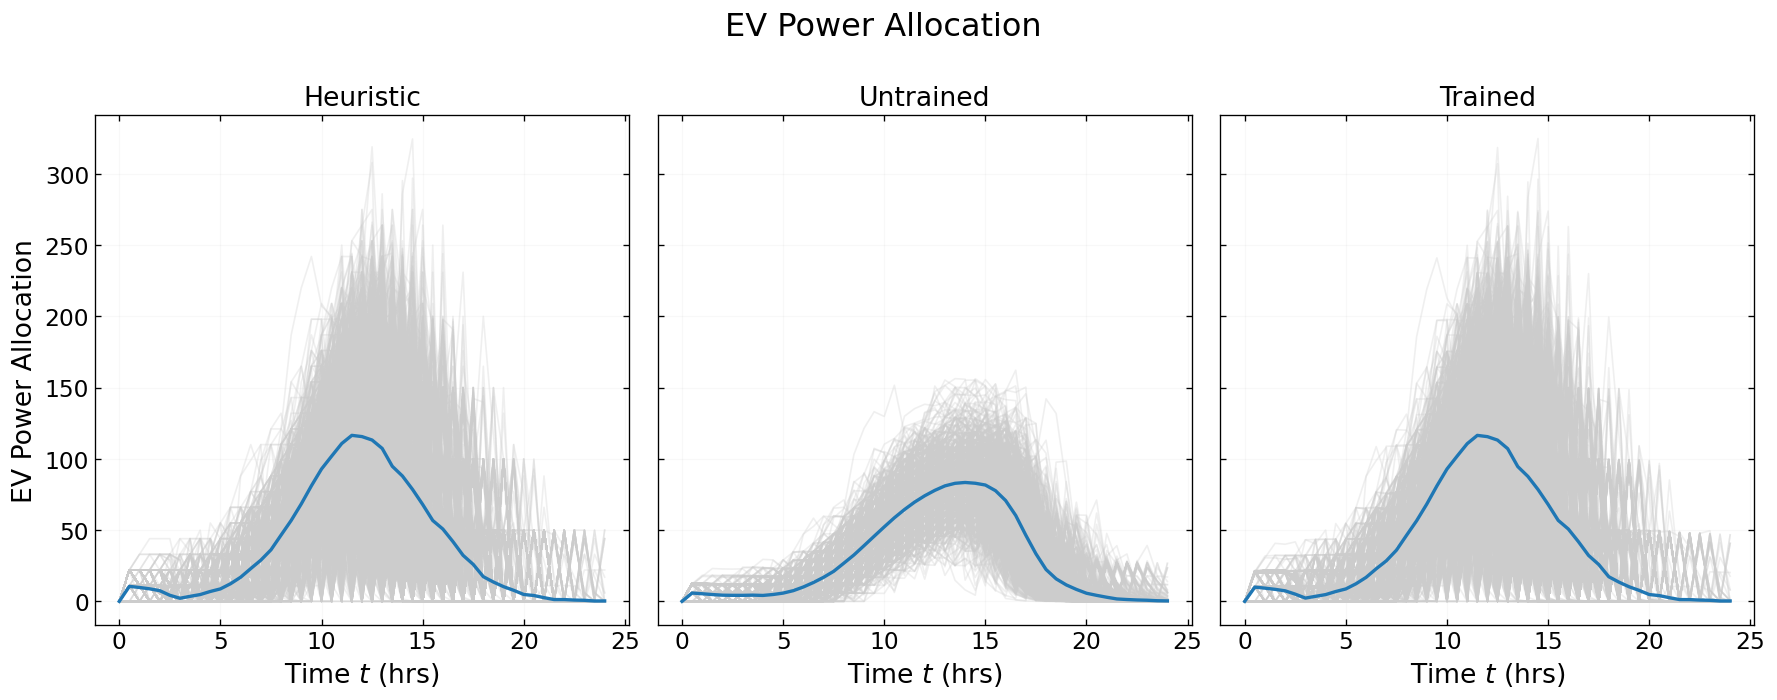

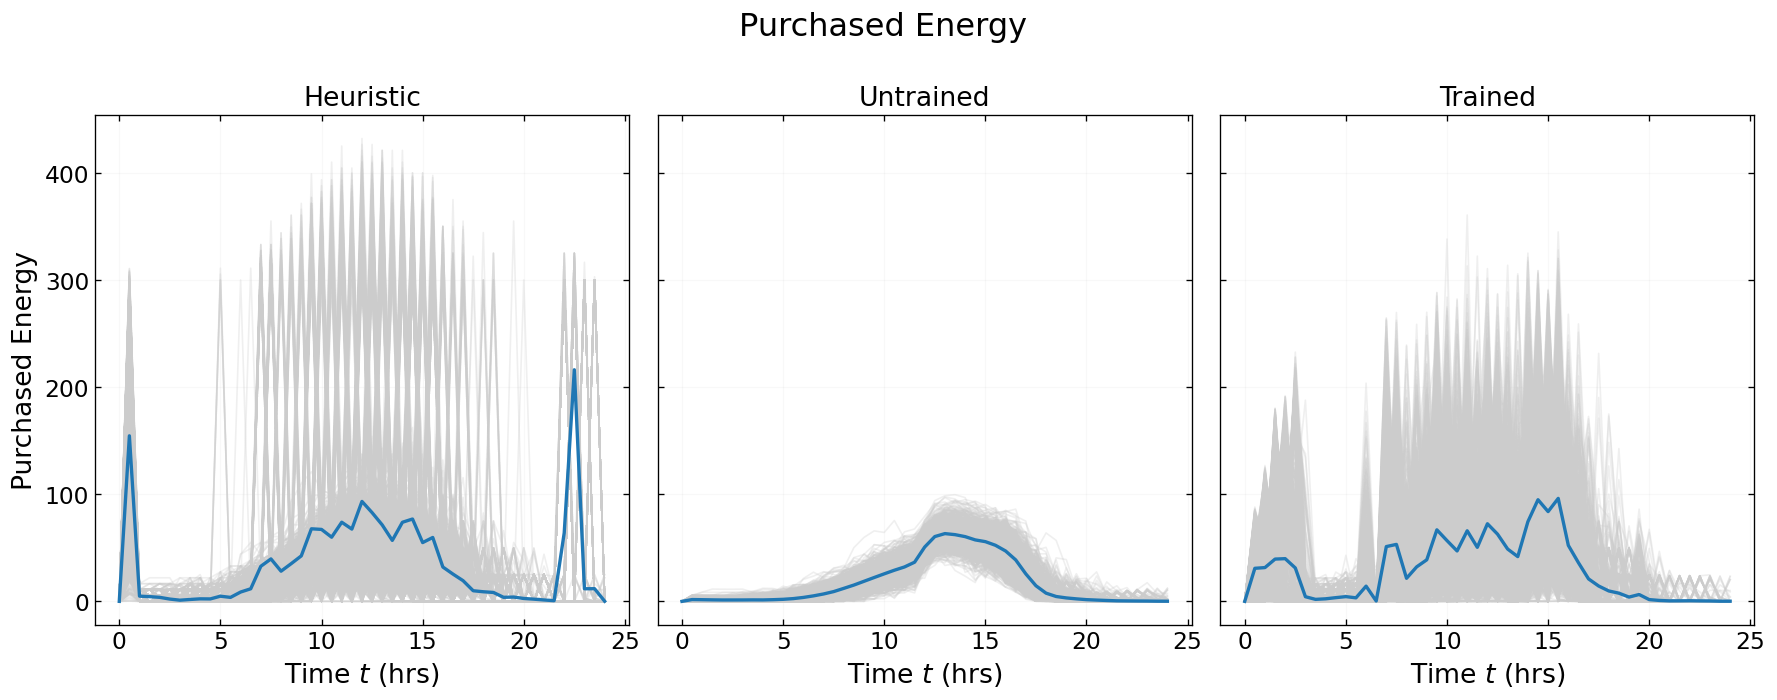

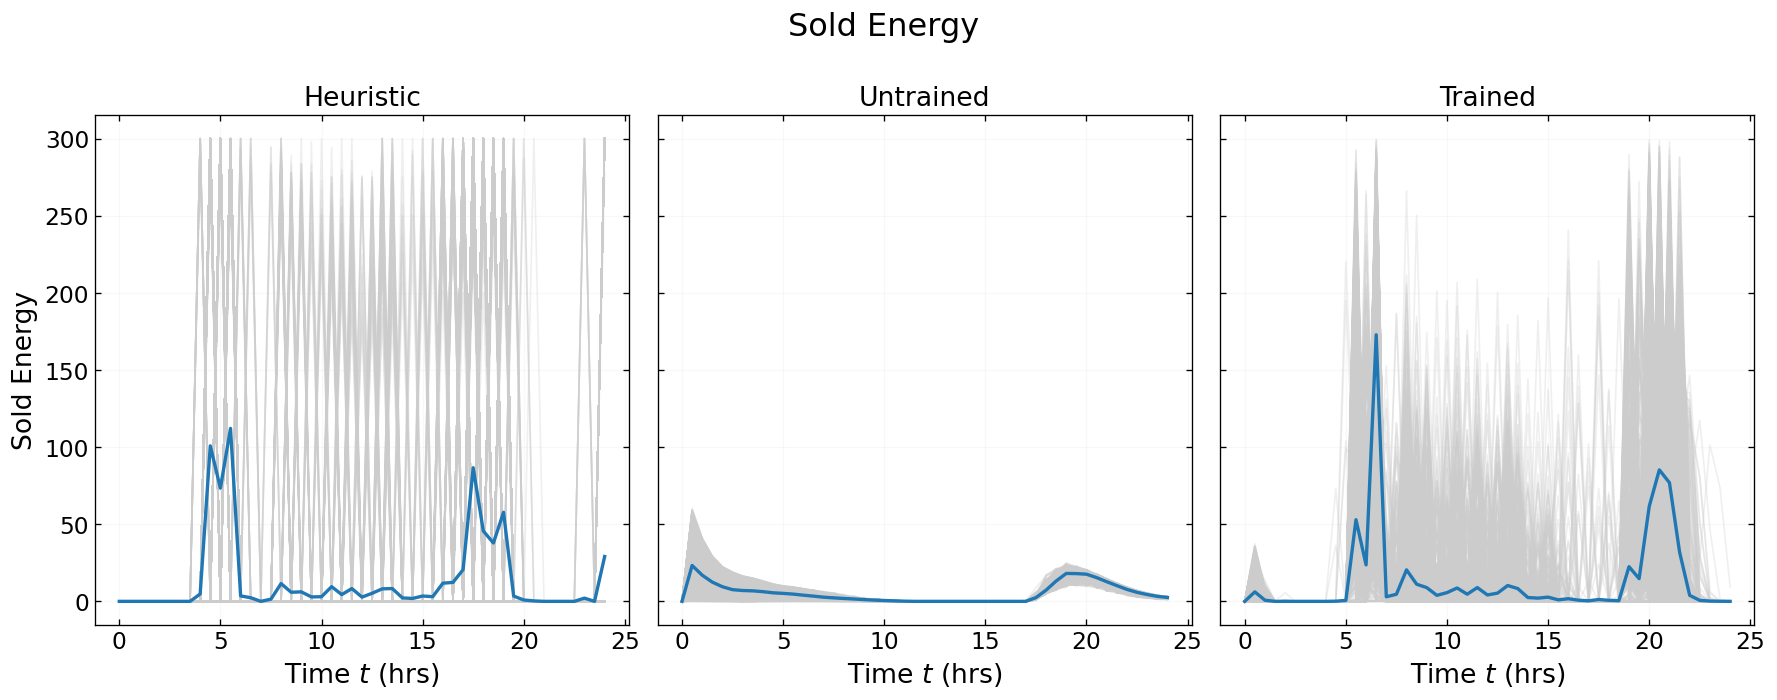

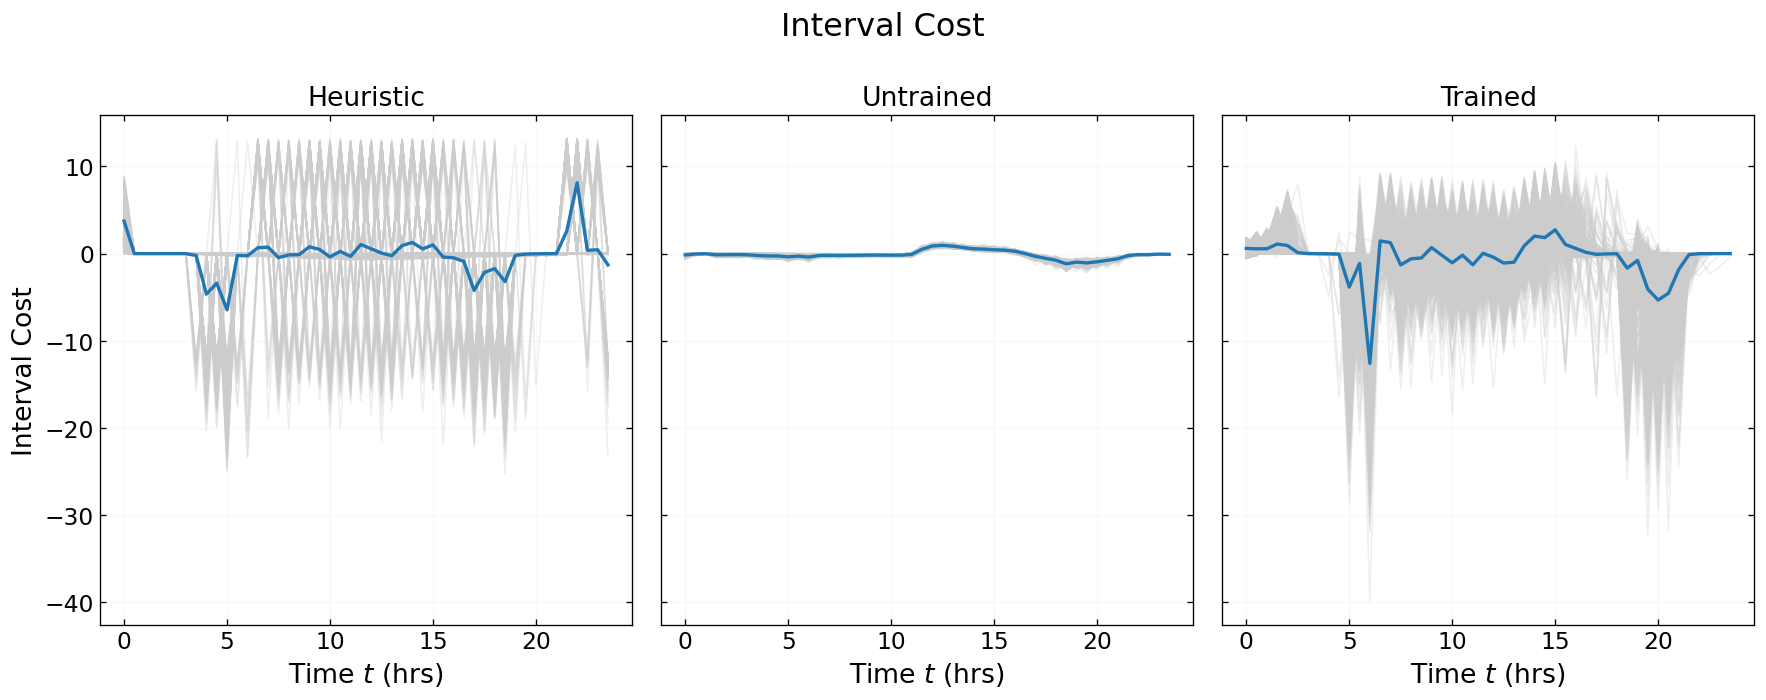

(<Figure size 1800x720 with 3 Axes>,
 array([<Axes: title={'center': 'Heuristic'}, xlabel='Time $t$ (hrs)', ylabel='Interval Cost'>,
        <Axes: title={'center': 'Untrained'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Trained'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [25]:
plot_variable_across_policies(
    results,
    "P",
    "Energy Price",
    #"../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "E",
    "Stored Energy",
    "../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "q",
    "EV Power Allocation",
    "../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "Ub",
    "Purchased Energy",
    "../figures/policy_comparison/purchased_energy.pdf"
)

plot_variable_across_policies(
    results,
    "Us",
    "Sold Energy",
    "../figures/policy_comparison/sold_energy.pdf"
)

plot_variable_across_policies(
    results,
    "c",
    "Interval Cost",
    "../figures/policy_comparison/interval_cost.pdf"
)

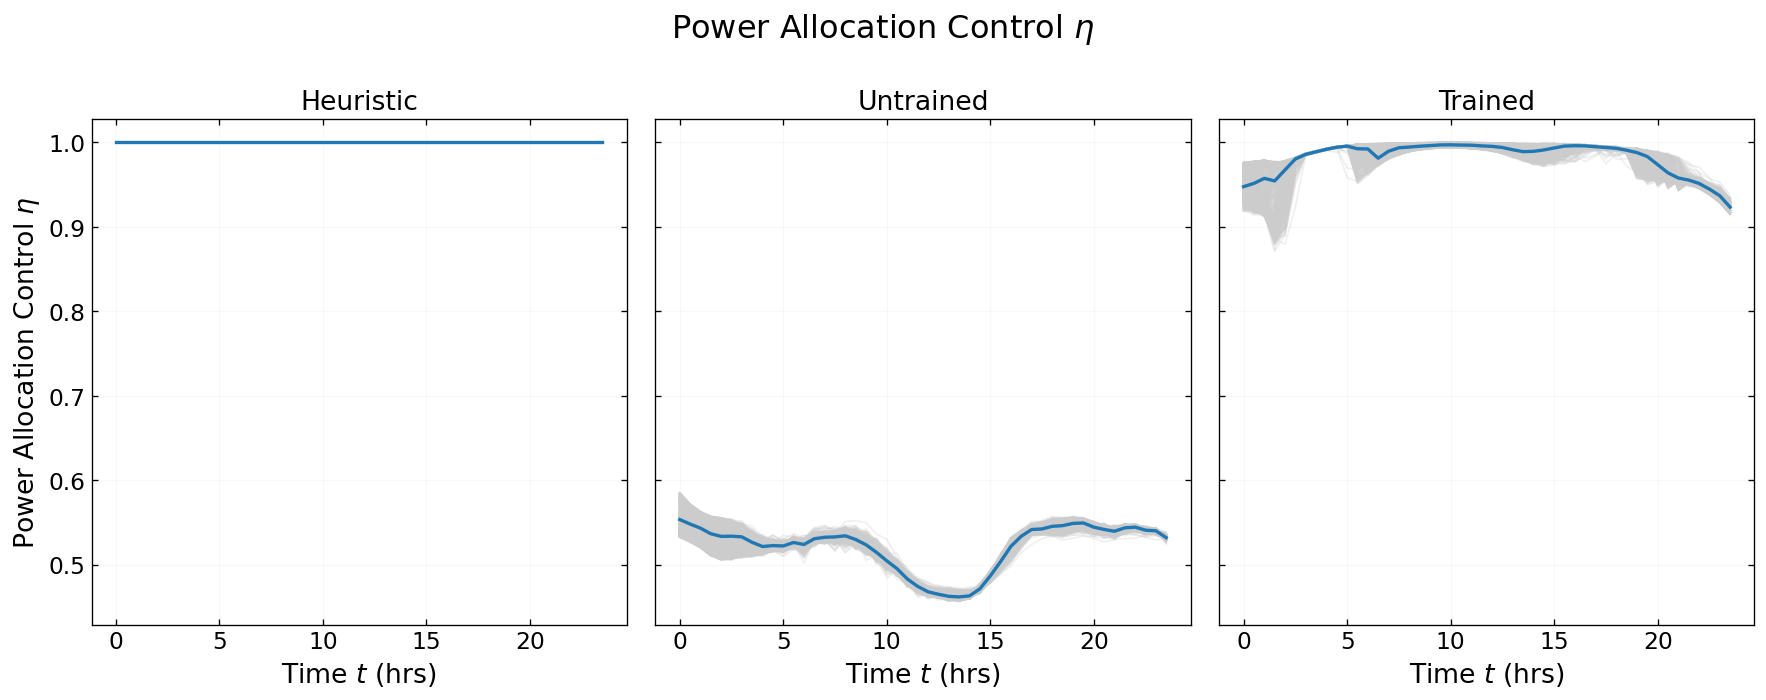

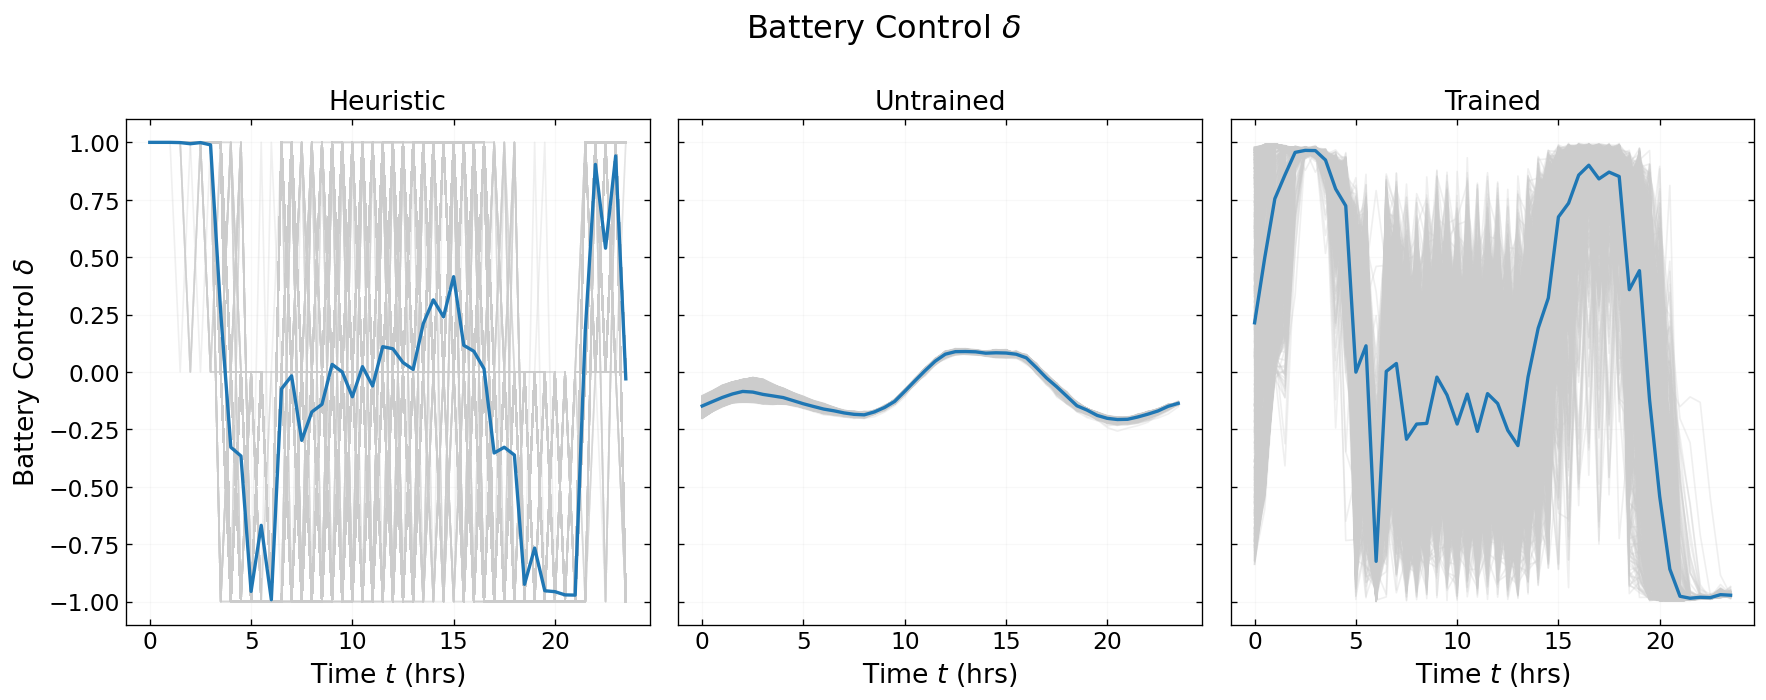

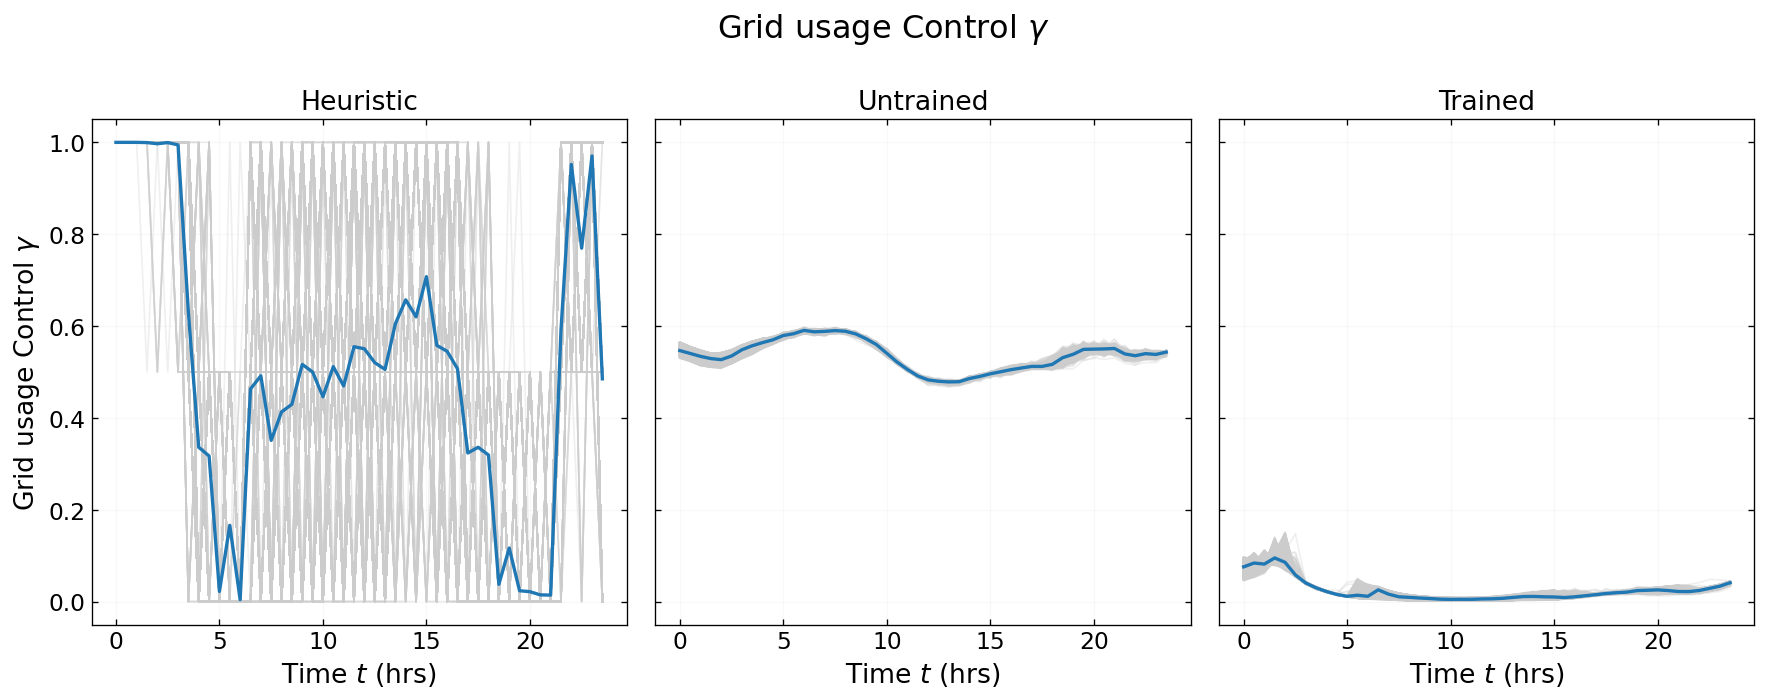

(<Figure size 1800x720 with 3 Axes>,
 array([<Axes: title={'center': 'Heuristic'}, xlabel='Time $t$ (hrs)', ylabel='Grid usage Control $\\gamma$'>,
        <Axes: title={'center': 'Untrained'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Trained'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [26]:
plot_variable_across_policies(
    results,
    "eta",
    "Power Allocation Control $\eta$",
    #"../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "delta",
    "Battery Control $\delta$",
    #"../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "gamma",
    "Grid usage Control $\gamma$",
    #"../figures/policy_comparison/purchased_energy.pdf"
)

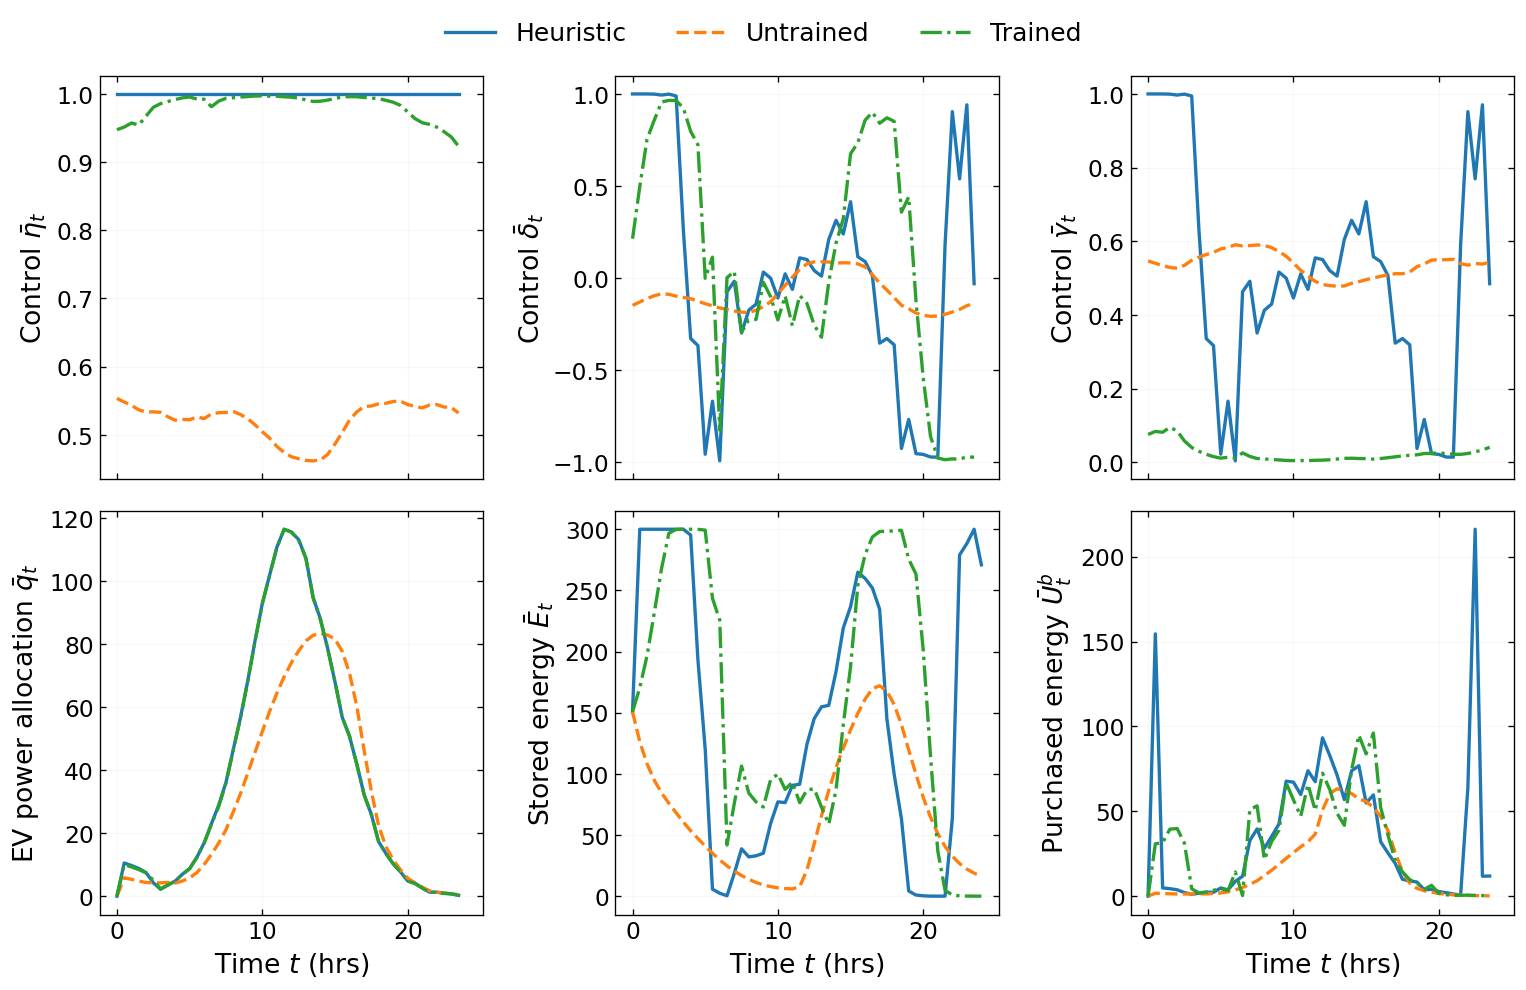

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: ylabel='Control $\\bar{\\eta}_t$'>,
        <Axes: ylabel='Control $\\bar{\\delta}_t$'>,
        <Axes: ylabel='Control $\\bar{\\gamma}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='EV power allocation $\\bar{q}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='Stored energy $\\bar{E}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='Purchased energy $\\bar{U}^{b}_t$'>],
       dtype=object))

In [27]:
plot_controls_summary(
    results,
    "../figures/policy_comparison/controls_summary.pdf"
)

In [28]:
from source.utils import summarize_histories

df = summarize_histories(results)
print(df.round(4))

            heuristic  untrained   trained
N_mean         7.6744     7.6744    7.6744
N_std          6.1878     6.1878    6.1878
D_mean        27.2015    61.4483   27.4087
D_std         37.8387    75.5498   37.9991
E_mean       146.2502    68.8598  159.8571
E_std        148.9382    57.8821  126.9547
P_mean         0.0420     0.0420    0.0420
P_std          0.0157     0.0157    0.0157
eta_mean       1.0000     0.5212    0.9815
eta_std        0.0000     0.0279    0.0210
delta_mean     0.0150    -0.0875    0.0907
delta_std      0.7190     0.0993    0.7164
gamma_mean     0.5075     0.5363    0.0242
gamma_std      0.3595     0.0334    0.0240
q_mean        36.6836    29.2755   36.6100
q_std         51.2065    33.6051   51.0535
ec_mean       17.2314     3.3896   15.1522
ec_std        67.5928     6.8119   37.9299
ed_mean       14.7796     6.1348   18.2290
ed_std        64.9271     7.6094   47.5651
Ub_mean       34.9422    17.2524   29.0236
Ub_std        72.7133    22.4294   48.3864
Us_mean    

In [29]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

In [30]:
import matplotlib.pyplot as plt
import sys

from source.plotting import *

sys.path.append("..")
plt.style.use("../styles/notebook.mplstyle")

In [31]:
from pathlib import Path

save_dir = Path("../figures/policy_comparison")
save_dir.mkdir(parents=True, exist_ok=True)

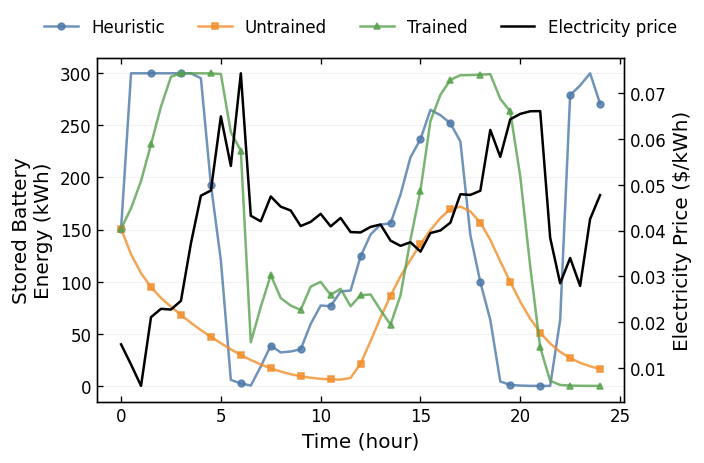

In [32]:
fig, ax1 = plt.subplots(figsize=(6, 4))

trained_history = results["trained"]

price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)
time = trained_history["time"].detach().numpy()


ax1, handles, labels = plot_policy_metric(
    results,
    metric_key="state",
    metric_idx=2,
    ax=ax1,
)

ax1.set_ylabel("Stored Battery\nEnergy (kWh)")

ax2 = ax1.twinx()

line_price = ax2.plot(
    time,
    price_mean,
    color="black",
    lw=1.5,
    label="Electricity Price",
)

handles += line_price
labels += ["Electricity Price"]

labels = [l.capitalize() for l in labels]

ax1.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
)

ax2.grid(False)
ax2.set_ylabel("Electricity Price ($/kWh)")

plt.tight_layout()
fig.savefig(save_dir / "stored_battery_energy_price.pdf")
plt.show()

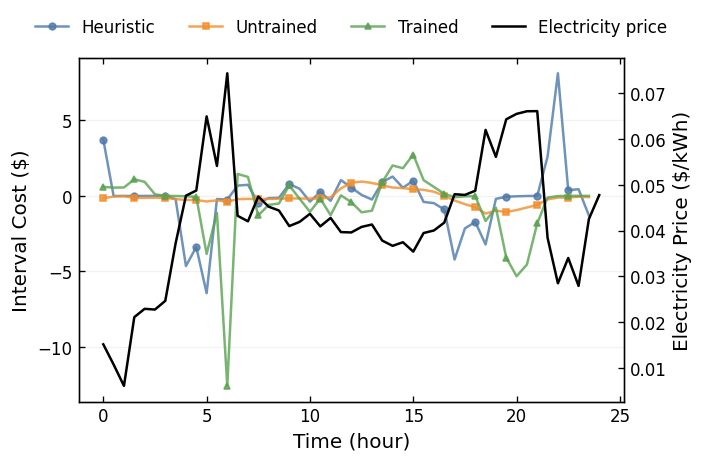

In [33]:
fig, ax1 = plt.subplots(figsize=(6, 4))

trained_history = results["trained"]

price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)
time = trained_history["time"].detach().numpy()


ax1, handles, labels = plot_policy_metric(
    results,
    metric_key="cost",
    ax=ax1,
)

ax1.set_ylabel("Interval Cost ($)")

ax2 = ax1.twinx()

line_price = ax2.plot(
    time,
    price_mean,
    color="black",
    lw=1.5,
    label="Electricity Price",
)

handles += line_price
labels += ["Electricity Price"]

labels = [l.capitalize() for l in labels]

ax1.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
)

ax2.grid(False)
ax2.set_ylabel("Electricity Price ($/kWh)")

plt.tight_layout()
fig.savefig(save_dir / "interval_cost_price.pdf")
plt.show()

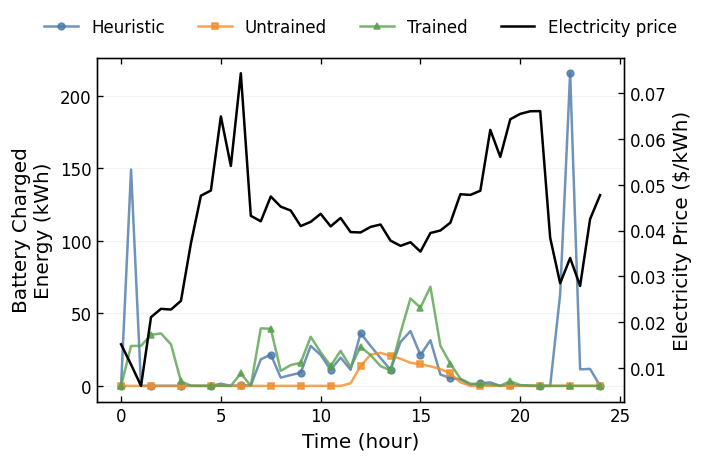

In [34]:
fig, ax1 = plt.subplots(figsize=(6, 4))

trained_history = results["trained"]

price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)
time = trained_history["time"].detach().numpy()


ax1, handles, labels = plot_policy_metric(
    results,
    metric_key="endog",
    metric_idx=1,
    ax=ax1,
)

ax1.set_ylabel("Battery Charged\nEnergy (kWh)")

ax2 = ax1.twinx()

line_price = ax2.plot(
    time,
    price_mean,
    color="black",
    lw=1.5,
    label="Electricity Price",
)

handles += line_price
labels += ["Electricity Price"]

labels = [l.capitalize() for l in labels]

ax1.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
)

ax2.grid(False)
ax2.set_ylabel("Electricity Price ($/kWh)")

plt.tight_layout()
fig.savefig(save_dir / "charged_energy_price.pdf")
plt.show()

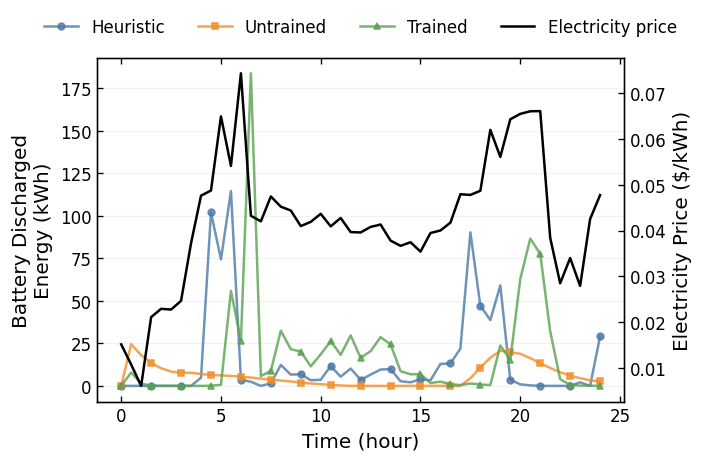

In [35]:
fig, ax1 = plt.subplots(figsize=(6, 4))

trained_history = results["trained"]

price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)
time = trained_history["time"].detach().numpy()


ax1, handles, labels = plot_policy_metric(
    results,
    metric_key="endog",
    metric_idx=2,
    ax=ax1,
)

ax1.set_ylabel("Battery Discharged\nEnergy (kWh)")

ax2 = ax1.twinx()

line_price = ax2.plot(
    time,
    price_mean,
    color="black",
    lw=1.5,
    label="Electricity Price",
)

handles += line_price
labels += ["Electricity Price"]

labels = [l.capitalize() for l in labels]

ax1.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
)

ax2.grid(False)
ax2.set_ylabel("Electricity Price ($/kWh)")

plt.tight_layout()
fig.savefig(save_dir / "discharged_energy_price.pdf")
plt.show()

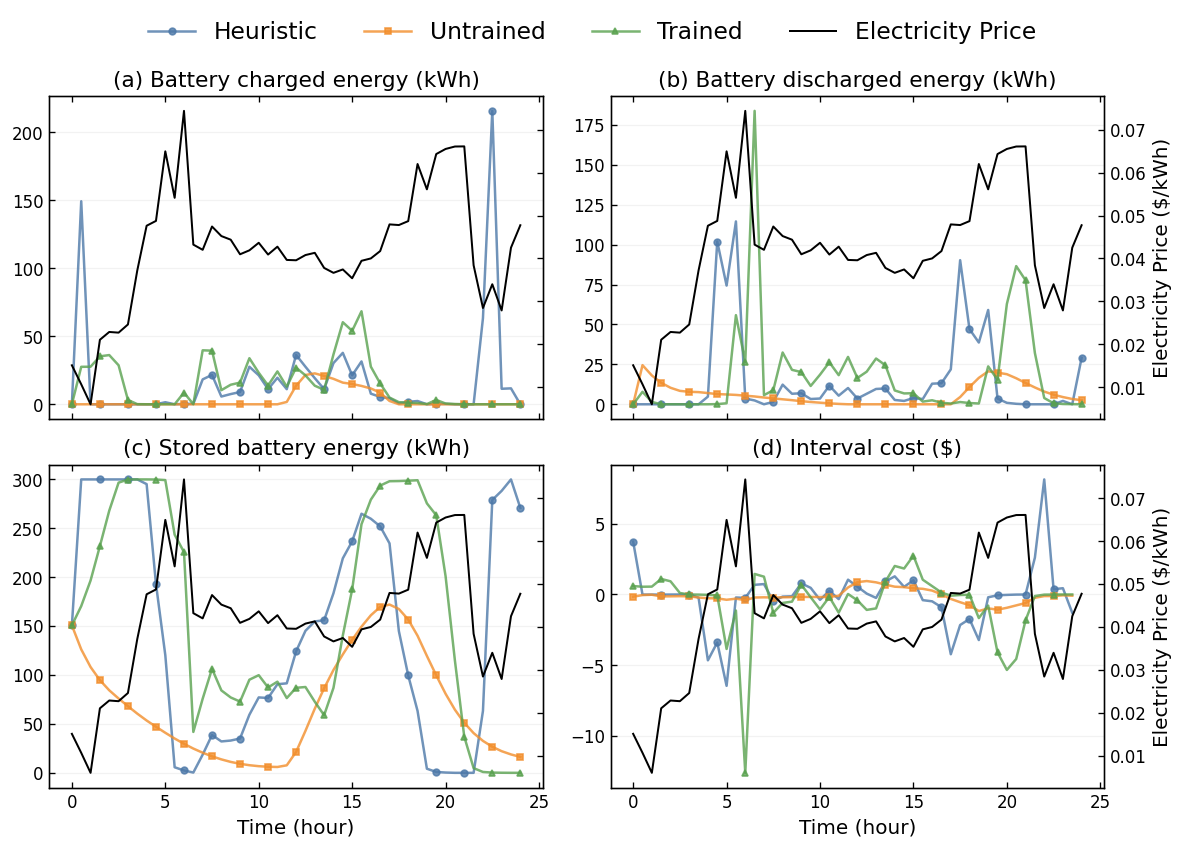

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

trained_history = results["trained"]
time = trained_history["time"].detach().numpy()
price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)

plots = [
    {
        "ax": axes[0, 0],
        "metric_key": "endog",
        "metric_idx": 1,
        "ylabel": "Battery Charged\nEnergy (kWh)",
        "title": "(a) Battery charged energy (kWh)",
    },
    {
        "ax": axes[0, 1],
        "metric_key": "endog",
        "metric_idx": 2,
        "ylabel": "Battery Discharged\nEnergy (kWh)",
        "title": "(b) Battery discharged energy (kWh)",
    },
    {
        "ax": axes[1, 0],
        "metric_key": "state",
        "metric_idx": 2,
        "ylabel": "Stored Battery\nEnergy (kWh)",
        "title": "(c) Stored battery energy (kWh)",
    },
    {
        "ax": axes[1, 1],
        "metric_key": "cost",
        "metric_idx": None,
        "ylabel": "Interval Cost ($)",
        "title": "(d) Interval cost ($)",
    },
]

legend_handles = None
legend_labels = None

for i, item in enumerate(plots):
    ax1 = item["ax"]

    ax1, handles, labels = plot_policy_metric(
        results,
        metric_key=item["metric_key"],
        metric_idx=item["metric_idx"],
        ax=ax1,
    )

    ax1.set_title(item["title"])
    if i < 2:
        ax1.set_xlabel("")
    

    ax2 = ax1.twinx()
    line_price = ax2.plot(
        time,
        price_mean,
        color="black",
        lw=1.2,
        label="Electricity Price",
    )

    if i % 2 == 1:
        ax2.set_ylabel("Electricity Price ($/kWh)")
    else:
        ax2.set_yticklabels([])
    ax2.grid(False)

    if legend_handles is None:
        legend_handles = handles + line_price
        legend_labels = [l.capitalize() for l in labels] + ["Electricity Price"]

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=14,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(save_dir / "policy_comparison_endog_price.pdf", bbox_inches="tight")
plt.show()

In [37]:
import numpy as np

Js = []

for seed in range(10000, 10100):

    next_price_fn = make_price_function(
        price_history,
        future_price,
        params
    )

    history = rollout_trajectory(
        policy=policy,
        S0=S0,
        params=params,
        next_price_fn=next_price_fn,
        stochastic=True,
        alpha_grid=0.0,
        lambda_demand=0.0,
        lambda_cost=0.0,
        seed=seed,
        device=device,
    )

    Js.append(history["J_episode"].item())

Js = np.array(Js)

print(f"Mean J : {Js.mean():.4f}")
print(f"Std J  : {Js.std():.4f}")
print(f"Min J  : {Js.min():.4f}")
print(f"Max J  : {Js.max():.4f}")

Mean J : -27.6545
Std J  : 0.1501
Min J  : -28.0115
Max J  : -27.0289


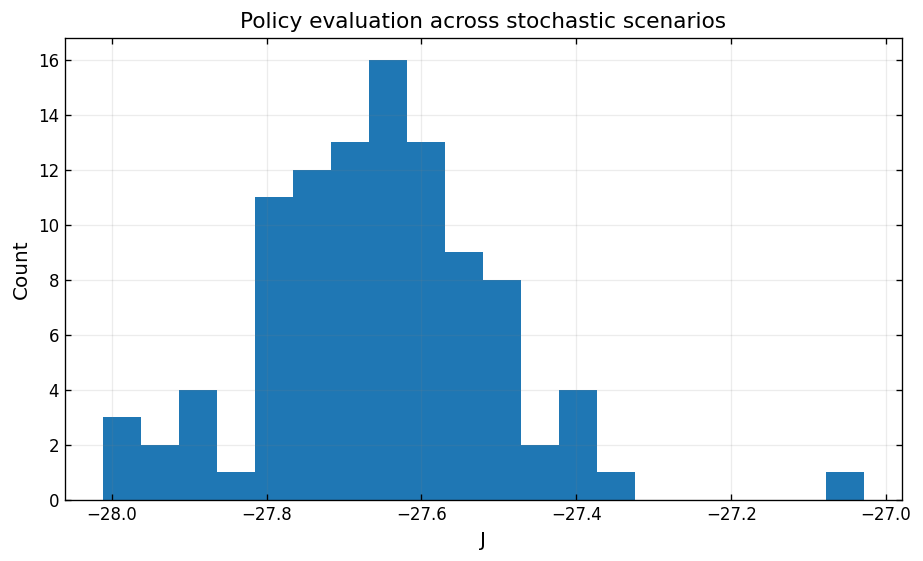

In [39]:
plt.hist(Js, bins=20)
plt.xlabel("J")
plt.ylabel("Count")
plt.title("Policy evaluation across stochastic scenarios")
plt.show()